# 03. Evaluación del Modelo y Sistema Experto Híbrido
En este notebook evaluaremos el modelo de clasificación **LGBMClassifier** utilizando técnicas de sobremuestreo con **SMOTEENN**. Además, aplicaremos validación cruzada, ajustaremos el umbral de decisión (Threshold Tuning) y finalmente aplicaremos nuestra **Regla de Negocio (Sistema Experto)** para salvar a los estudiantes con promedios excelentes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score, precision_recall_curve, f1_score)

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")

## 1. Carga y Transformación Binaria de la Variable Objetivo

In [2]:
# Cargar tabla maestra
df = pd.read_csv('../data/03_primary/tabla_maestra.csv')

# Normalizar estado de matrícula
df['estado_matricula'] = df['estado_matricula'].str.strip().str.upper()

# Estrategia Binaria: Agrupar en NO_RIESGO (0) y BAJA_RETENCION (1)
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')
df['estado_matricula'] = df['estado_matricula'].replace(['REGULAR', 'EGRESADO'], 'NO_RIESGO')

target_map = {'NO_RIESGO': 0, 'BAJA_RETENCION': 1}
df['target_bin'] = df['estado_matricula'].map(target_map)

# Definir variables
num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "target_bin"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

# Split (usando la semilla óptima 44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44, stratify=y)
print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (424, 5), Prueba: (107, 5)


## 2. Pipeline: Preprocesamiento + SMOTEENN + LightGBM

In [3]:
# Definir preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Definir pipeline con Imblearn (SMOTEENN) y LightGBM
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

# Entrenamiento
pipeline.fit(X_train, y_train)
print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 3. Validación Cruzada y Matriz de Confusión Binaria

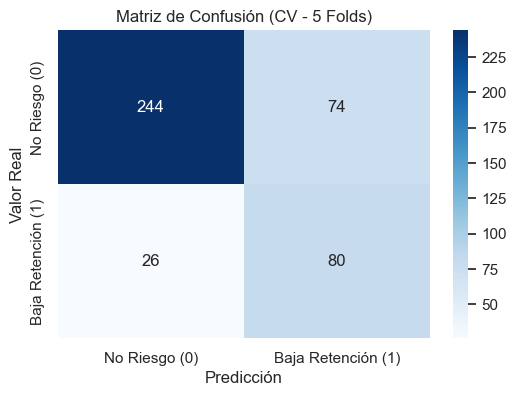

In [4]:
# Cross Validation Predictions
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv)

cm_cv = confusion_matrix(y_train, y_pred_cv)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Riesgo (0)', 'Baja Retención (1)'], 
            yticklabels=['No Riesgo (0)', 'Baja Retención (1)'])
plt.title('Matriz de Confusión (CV - 5 Folds)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

## 4. Curva ROC y Curva Precision-Recall

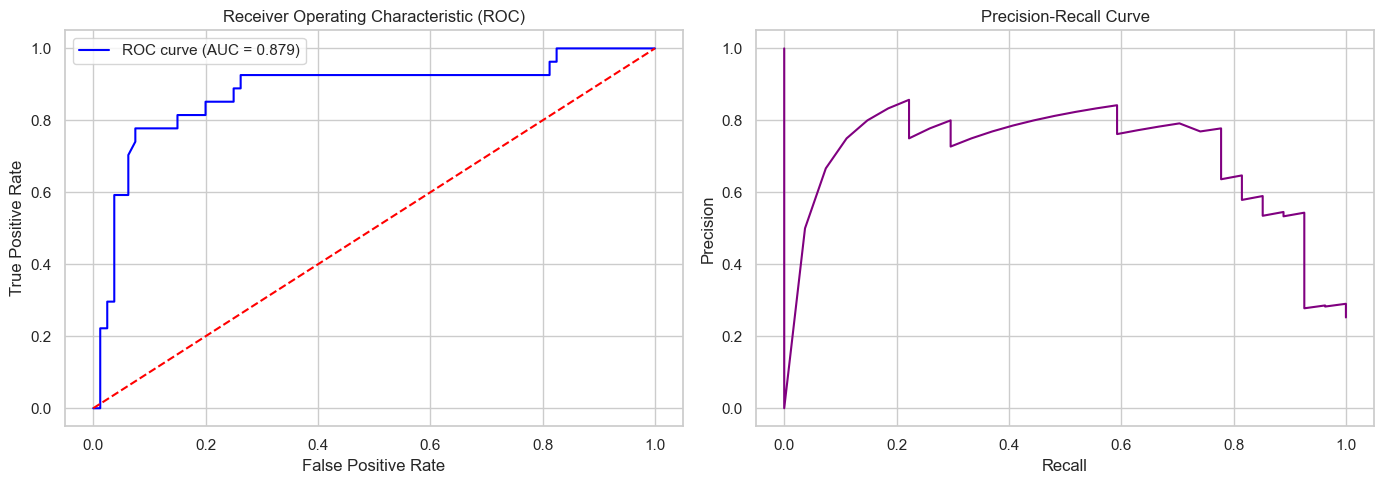

In [5]:
# Predicciones probabilísticas en test
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Calcular ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Calcular Precision-Recall
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax1.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.3f})')
ax1.plot([0, 1], [0, 1], color='red', linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend()

# Curva PR
ax2.plot(recalls, precisions, color='purple')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## 5. Threshold Tuning y Sistema Experto Híbrido

In [6]:
# Encontrar el mejor umbral maximizando F1-Score
f1_scores = [0.0 if (p + r) == 0 else 2 * (p * r) / (p + r) for p, r in zip(precisions[:-1], recalls[:-1])]
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]

print(f"=== Umbral Matemático Óptimo de Predicción: {best_threshold:.4f} ===")

# Aplicar umbral matemático
y_pred_base = (y_probs >= best_threshold).astype(int)

# SISTEMA EXPERTO HÍBRIDO (Regla de Negocio)
# Si el modelo predice 1 (Riesgo), pero el alumno tiene promedio >= 6.0, forzamos la predicción a 0.
y_pred_expert = y_pred_base.copy()
mask_override = (y_pred_expert == 1) & (X_test['promedio_notas'] >= 6.0)

num_salvados = mask_override.sum()
y_pred_expert[mask_override] = 0

print(f"El Sistema Experto corrigió (salvó) a {num_salvados} estudiantes con excelencia académica.\n")

# Reporte Final
target_names = ['NO_RIESGO (0)', 'BAJA_RETENCION (1)']
print("=== Classification Report Final (Híbrido) ===")
print(classification_report(y_test, y_pred_expert, target_names=target_names))

=== Umbral Matemático Óptimo de Predicción: 0.9559 ===
El Sistema Experto corrigió (salvó) a 2 estudiantes con excelencia académica.

=== Classification Report Final (Híbrido) ===
                    precision    recall  f1-score   support

     NO_RIESGO (0)       0.93      0.95      0.94        80
BAJA_RETENCION (1)       0.84      0.78      0.81        27

          accuracy                           0.91       107
         macro avg       0.88      0.86      0.87       107
      weighted avg       0.90      0.91      0.91       107

